In [1]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

from tqdm import tqdm



# np.set_printoptions(precision=4)

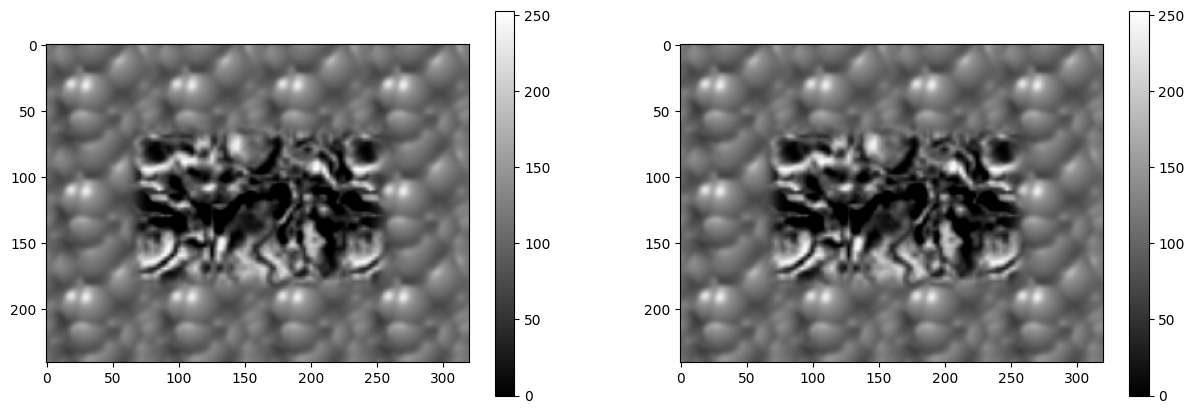

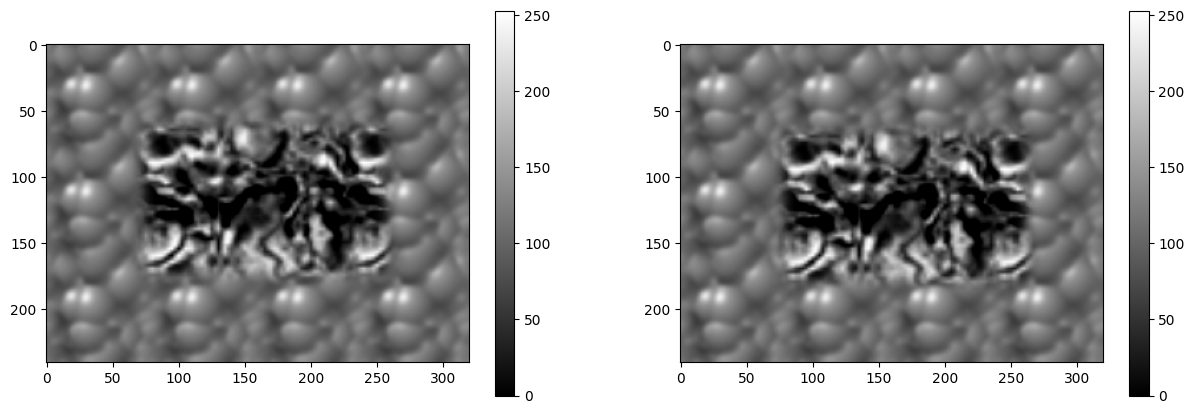

In [45]:
input_dir = Path('TestSeq')

shift_0 = cv.imread(str(input_dir / 'Shift0.png'), cv.IMREAD_GRAYSCALE)
shift_r2 = cv.imread(str(input_dir / 'ShiftR2.png'), cv.IMREAD_GRAYSCALE)
shift_r5u5 = cv.imread(str(input_dir / 'ShiftR5U5.png'), cv.IMREAD_GRAYSCALE)
shift_r10 = cv.imread(str(input_dir / 'ShiftR10.png'), cv.IMREAD_GRAYSCALE)
shift_r20 = cv.imread(str(input_dir / 'ShiftR20.png'), cv.IMREAD_GRAYSCALE)
shift_r40 = cv.imread(str(input_dir / 'ShiftR40.png'), cv.IMREAD_GRAYSCALE)

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(shift_0, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(shift_r2, cmap="gray")
plt.colorbar()
plt.show()


plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(shift_r5u5, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(shift_r10, cmap="gray")
plt.colorbar()
plt.show()

In [155]:
def gradients(img, kernel_size=3, sigma=3):
    # img = img.copy().astype(np.float32)
    img = cv.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=kernel_size)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=kernel_size)

    # sobelx = np.uint8(np.absolute(sobelx))    
    # sobely = np.uint8(np.absolute(sobely))    
    return sobelx, sobely

def time_gradient(imgt1, imgt2):
    # return imgt1 - imgt2
    return imgt2 - imgt1


def displacement_vector(Ix, Iy, It, window_size=3):
    sum_window = lambda I: cv.filter2D(I, ddepth=-1, kernel=np.ones((window_size, window_size), np.float32))
    # sum_window = lambda I: cv.GaussianBlur(I, (window_size, window_size), 5)

    summed_Ix2 = sum_window(Ix * Ix)
    summed_Iy2 = sum_window(Iy * Iy)
    summed_IxIy = sum_window(Ix * Iy)
    summed_IxIt = sum_window(Ix * It)
    summed_IyIt = sum_window(Iy * It)


    ATA = lambda i,j: np.array([[summed_Ix2[i,j], summed_IxIy[i,j]], 
                                  [summed_IxIy[i,j], summed_Iy2[i,j]]])
    ATb = lambda i,j: -1 * np.array([summed_IxIt[i,j], summed_IyIt[i,j]])

    u = np.zeros_like(Ix, dtype=np.float32)
    v = np.zeros_like(Ix, dtype=np.float32)

    # Populate the image using the function
    for i in range(u.shape[0]):
        for j in range(u.shape[1]):
            u[i,j], v[i,j] = solve(ATA(i,j), ATb(i,j))

    return u,v

def solve(A, b):
    return np.linalg.lstsq(A,b)[0]

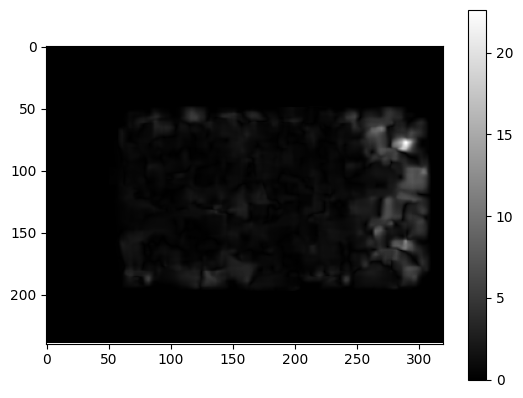

In [156]:
img = shift_0
imgt2 = shift_r40
k_size = 15
[Ix, Iy], It = gradients(img), time_gradient(img, imgt2)
u,v = displacement_vector(Ix,Iy,It,k_size)
plt.imshow(np.sqrt(np.square(u) + np.square(v)), cmap="gray")
plt.colorbar()
plt.show()

## Part 2
In lectures we described the Gaussian pyramid constructed using the REDUCE operator. Here is the original paper that defines the REDUCE and EXPAND operators:


### A

Write a function to implement REDUCE. Use this to produce a Gaussian Pyramid of 4 levels (0-3). Demonstrate using the first frame of the DataSeq1 sequence.

In [ ]:
def REDUCE(img, levels):
    pass



### B 

Although the Lucas and Kanade method does not use the Laplacian Pyramid, you do need to expand the warped coarser levels (more on this in a minute). Therefore you will need to implement the EXPAND operator. Once you have that the Laplacian Pyramid is just some subtractions.
Write the function EXPAND. Using it and the above REDUCE, create the 4 level Laplacian pyramid of DataSeq1 (which has 1 Gaussian image and the 3 Laplacian images).